In [1]:
!git clone https://github.com/njavid/PRISM



Cloning into 'PRISM'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (205/205), done.
remote: Compressing objects: 100% (198/198), done.
remote: Total 205 (delta 80), reused 19 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (205/205), 23.26 MiB | 16.33 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [2]:
%cd PRISM

/content/PRISM


In [3]:
# !git pull

In [4]:
# !git reset --hard 8fdb21300dd87c0eedea2f6e6f2f1fe3aadbcd2a

In [5]:

!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install git+https://github.com/deepmind/surface-distance.git

!pip install connected-components-3d prefetch_generator kornia torchio monai

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-afmt1mqs
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-afmt1mqs
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=59823e5cd4742e18ecd357e4fea5822050e384163ca303a976e4512cbcccee24
  Stored in directory: /tmp/pip-ephem-wheel-cache-aex7lfhk/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything
  Cloning https://github.com/deepmind/surface-distance.git to /tmp/pip-req-build-emjqnuw4
  Running command git clone --filter=blob:none --quiet https://github.com/deepmind/surface-distance.git /tmp/pip-req-build-emjqnuw4
  Resolved https://github.com/deepmind/surface-dis

In [6]:
# download data (part of)
!gdown 1MA_uvgwtIVNhK__kzZBiIThAR2nGLcNt

Downloading...
From (original): https://drive.google.com/uc?id=1MA_uvgwtIVNhK__kzZBiIThAR2nGLcNt
From (redirected): https://drive.google.com/uc?id=1MA_uvgwtIVNhK__kzZBiIThAR2nGLcNt&confirm=t&uuid=f0c961b3-761b-4cb9-b322-2aec5c1f4510
To: /content/PRISM/kits_40.zip
100% 3.49G/3.49G [00:31<00:00, 111MB/s]


In [7]:
!unzip kits_40

Streaming output truncated to the last 5000 lines.
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/tumor_instance-1_annotation-1.nii.gz  
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/kidney_instance-1_annotation-1.nii.gz  
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/kidney_instance-1_annotation-2.nii.gz  
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/tumor_instance-2_annotation-1.nii.gz  
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/tumor_instance-2_annotation-3.nii.gz  
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00001/segmentations/tumor_instance-2_annotation-2.nii.gz  
   creating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00002/
  inflating: content/drive/MyDrive/PHD/IABI/project/kits_40/case_00002/aggregated_OR_seg.nii.gz  
  inflating: content/drive/MyDriv

In [8]:
!ls

content  figs  kits_40.zip  LICENSE  README.md	requirements.txt  splits  src


In [9]:
!mv content/drive/MyDrive/PHD/IABI/project/kits_40/ /content/PRISM

In [10]:
import pickle

with open('/content/PRISM/kits_40/split.pkl', 'rb') as f:
    split = pickle.load(f)

print(type(split))
print(split.keys() if isinstance(split, dict) else "Not dict")
print(len(split[0]['val']))
print(split[0]['val'])

<class 'list'>
Not dict
30
{'case_00212': ['case_00212/imaging.nii.gz', 'case_00212/aggregated_MAJ_seg.nii.gz'], 'case_00289': ['case_00289/imaging.nii.gz', 'case_00289/aggregated_MAJ_seg.nii.gz'], 'case_00145': ['case_00145/imaging.nii.gz', 'case_00145/aggregated_MAJ_seg.nii.gz'], 'case_00114': ['case_00114/imaging.nii.gz', 'case_00114/aggregated_MAJ_seg.nii.gz'], 'case_00045': ['case_00045/imaging.nii.gz', 'case_00045/aggregated_MAJ_seg.nii.gz'], 'case_00116': ['case_00116/imaging.nii.gz', 'case_00116/aggregated_MAJ_seg.nii.gz'], 'case_00034': ['case_00034/imaging.nii.gz', 'case_00034/aggregated_MAJ_seg.nii.gz'], 'case_00049': ['case_00049/imaging.nii.gz', 'case_00049/aggregated_MAJ_seg.nii.gz'], 'case_00059': ['case_00059/imaging.nii.gz', 'case_00059/aggregated_MAJ_seg.nii.gz'], 'case_00256': ['case_00256/imaging.nii.gz', 'case_00256/aggregated_MAJ_seg.nii.gz'], 'case_00076': ['case_00076/imaging.nii.gz', 'case_00076/aggregated_MAJ_seg.nii.gz'], 'case_00030': ['case_00030/imaging.ni

In [28]:
import pickle

split_path = "/content/PRISM/kits_40/split.pkl"

# کیس‌های معتبر
valid_cases = [f"case_{i:05d}" for i in range(4)]

# load
with open(split_path, "rb") as f:
    split = pickle.load(f)

print("Before filtering:")
print(split)

# چون ساختار: list -> dict -> 'train' -> dict
new_split = []

for item in split:
    new_item = {}
    for key in item.keys():
        if key == 'train':
            filtered_train = {
                case: paths
                for case, paths in item['train'].items()
                if case in valid_cases
            }
            new_item['train'] = filtered_train
        else:
            new_item[key] = item[key]
    new_split.append(new_item)

print("\nAfter filtering:")
print(new_split)

# save
with open(split_path, "wb") as f:
    pickle.dump(new_split, f)

print("\n✅ split.pkl updated correctly!")

Before filtering:
[{'train': {'case_00006': ['case_00006/imaging.nii.gz', 'case_00006/aggregated_MAJ_seg.nii.gz'], 'case_00001': ['case_00001/imaging.nii.gz', 'case_00001/aggregated_MAJ_seg.nii.gz'], 'case_00003': ['case_00003/imaging.nii.gz', 'case_00003/aggregated_MAJ_seg.nii.gz'], 'case_00004': ['case_00004/imaging.nii.gz', 'case_00004/aggregated_MAJ_seg.nii.gz'], 'case_00009': ['case_00009/imaging.nii.gz', 'case_00009/aggregated_MAJ_seg.nii.gz'], 'case_00000': ['case_00000/imaging.nii.gz', 'case_00000/aggregated_MAJ_seg.nii.gz'], 'case_00010': ['case_00010/imaging.nii.gz', 'case_00010/aggregated_MAJ_seg.nii.gz']}, 'val': {}, 'test': {'case_00125': ['case_00125/imaging.nii.gz', 'case_00125/aggregated_MAJ_seg.nii.gz'], 'case_00238': ['case_00238/imaging.nii.gz', 'case_00238/aggregated_MAJ_seg.nii.gz'], 'case_00038': ['case_00038/imaging.nii.gz', 'case_00038/aggregated_MAJ_seg.nii.gz'], 'case_00105': ['case_00105/imaging.nii.gz', 'case_00105/aggregated_MAJ_seg.nii.gz'], 'case_00254': 

In [23]:
import pickle

split_path = "/content/PRISM/kits_40/split.pkl"

# کیس‌های معتبر
valid_cases = [f"case_{i:05d}" for i in range(39,40)]

# load
with open(split_path, "rb") as f:
    split = pickle.load(f)

print("Before filtering:")
print(split)

# چون ساختار: list -> dict -> 'train' -> dict
new_split = []

for item in split:
    new_item = {}
    for key in item.keys():
        if key == 'val':
            filtered_train = {
                case: paths
                for case, paths in item['val'].items()
                if case in valid_cases
            }
            new_item['val'] = filtered_train
        else:
            new_item[key] = item[key]
    new_split.append(new_item)

print("\nAfter filtering:")
print(new_split)

# save
with open(split_path, "wb") as f:
    pickle.dump(new_split, f)

print("\n✅ split.pkl updated correctly!")

Before filtering:
[{'train': {'case_00006': ['case_00006/imaging.nii.gz', 'case_00006/aggregated_MAJ_seg.nii.gz'], 'case_00001': ['case_00001/imaging.nii.gz', 'case_00001/aggregated_MAJ_seg.nii.gz'], 'case_00003': ['case_00003/imaging.nii.gz', 'case_00003/aggregated_MAJ_seg.nii.gz'], 'case_00004': ['case_00004/imaging.nii.gz', 'case_00004/aggregated_MAJ_seg.nii.gz'], 'case_00009': ['case_00009/imaging.nii.gz', 'case_00009/aggregated_MAJ_seg.nii.gz'], 'case_00000': ['case_00000/imaging.nii.gz', 'case_00000/aggregated_MAJ_seg.nii.gz'], 'case_00010': ['case_00010/imaging.nii.gz', 'case_00010/aggregated_MAJ_seg.nii.gz']}, 'val': {'case_00034': ['case_00034/imaging.nii.gz', 'case_00034/aggregated_MAJ_seg.nii.gz'], 'case_00030': ['case_00030/imaging.nii.gz', 'case_00030/aggregated_MAJ_seg.nii.gz']}, 'test': {'case_00125': ['case_00125/imaging.nii.gz', 'case_00125/aggregated_MAJ_seg.nii.gz'], 'case_00238': ['case_00238/imaging.nii.gz', 'case_00238/aggregated_MAJ_seg.nii.gz'], 'case_00038': ['

In [13]:
import os
os.environ['PYTHONPATH'] = '/content/PRISM'

In [14]:
!ls

content  kits_40      LICENSE	 requirements.txt  src
figs	 kits_40.zip  README.md  splits


In [15]:
# %cd content

In [26]:
!git pull

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 5 (delta 4), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.08 KiB | 138.00 KiB/s, done.
From https://github.com/njavid/PRISM
   71b4d8c..272b1a8  main       -> origin/main
Updating 71b4d8c..272b1a8
Fast-forward
 src/processor/trainer_basic.py | 4 ++--
 1 file changed, 2 insertions(+), 2 deletions(-)


In [31]:
!python src/train.py \
    --data colon \
    --data_dir kits_40 \
    --save_name seg_run \
    --num_workers 0 \
    --multiple_outputs --dynamic --use_box --refine\
    --max_epoch 5 \
    --iter_nums 1
    # --num_clicks 10


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-02-25 08:17:04.235918: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772007424.464359    4303 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772007424.530538    4303 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772007424.989362    4303 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772007424.989407    4303 computation_placer.cc:1

In [18]:
# %cd PRISM
# import os
# os.environ['PYTHONPATH'] = '/content/PRISM'

[Errno 2] No such file or directory: 'PRISM'
/content/PRISM


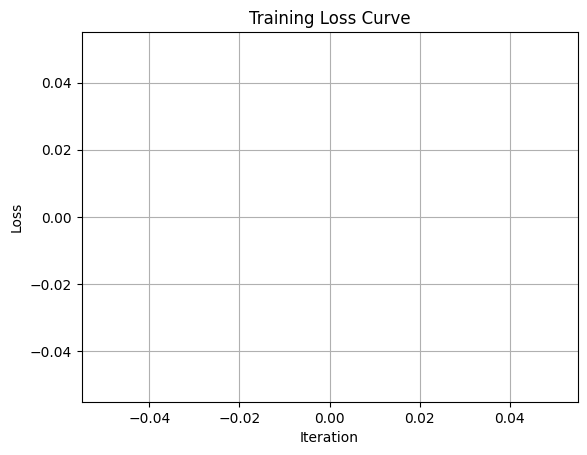

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Load all epoch loss files
loss_files = sorted(glob.glob("loss_logs/epoch_*_loss.npy"))

all_losses = []

for file in loss_files:
    losses = np.load(file)
    all_losses.extend(losses)

plt.figure()
plt.plot(all_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [20]:
# !python test.py \
#     --data colon \
#     --data_dir ./PRISM_data \
#     --split test \
#     --checkpoint best \
#     --save_name prism_results \
#     --num_clicks 1 --iter_nums 11 \
#     --multiple_outputs --use_box --use_scribble --efficient_scribble --refine --refine_test


In [21]:
# import os

# output_zip_path = '/content/drive/MyDrive/kits_40.zip'
# folder_to_zip = '/content/drive/MyDrive/PHD/IABI/project/kits_40'

# # Ensure the parent directory for the zip file exists (MyDrive is usually already mounted)
# output_dir = os.path.dirname(output_zip_path)
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)

# # Check if the folder to zip exists
# if os.path.exists(folder_to_zip):
#     print(f"Zipping folder: {folder_to_zip} to {output_zip_path}")
#     !zip -r "{output_zip_path}" "{folder_to_zip}"
#     print("Zipping complete.")
# else:
#     print(f"Error: Folder not found at {folder_to_zip}")

In [22]:
# import os

# output_zip_path = '/content/drive/MyDrive/kits.zip'

# if os.path.exists(output_zip_path):
#     file_size_bytes = os.path.getsize(output_zip_path)
#     # Convert bytes to megabytes for better readability
#     file_size_mb = file_size_bytes / (1024 * 1024)
#     print(f"The size of '{output_zip_path}' is {file_size_bytes} bytes ({file_size_mb:.2f} MB).")
# else:
#     print(f"Error: The file '{output_zip_path}' does not exist.")